In [1]:
import Pkg

project_directory = normpath(
    joinpath(@__DIR__, "..", "..")
)

Pkg.activate(project_directory)
Pkg.instantiate()

println("Active project: ", Base.active_project())

using LongitudinalTomography
using CairoMakie
using Random
using Printf

println(
    "LongitudinalTomography loaded from: ",
    pathof(LongitudinalTomography),
)

  Activating project at `~/Desktop/longitudinal_dynamics`


Active project: /Users/gonza839/Desktop/longitudinal_dynamics/Project.toml
LongitudinalTomography loaded from: /Users/gonza839/Desktop/longitudinal_dynamics/src/LongitudinalTomography.jl


In [2]:
const PROTON_MASS_EV = 938.2720813e6
const TOTAL_ENERGY_EV = 8.0e9 + PROTON_MASS_EV
const GAMMA_S = TOTAL_ENERGY_EV / PROTON_MASS_EV
const BETA_S = sqrt(1 - 1 / GAMMA_S^2)

rf1 = SingleRFMachine(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-8.8e-3,
    beta_s=BETA_S,
    E_s_eV=TOTAL_ENERGY_EV,
    rf_kick_eV=60e3,
)

two_rf = NonInteractingTwoRFMachine(
    rf1;
    f_slip_hz=84 * 15.0,
    relative_phase0=0.0,
)

@printf("nu_s1                 = %.6f\n", synchrotron_tune(two_rf.rf1))
@printf("nu_slip               = %.6f\n", slip_tune(two_rf))
@printf("alpha_s               = %.3f\n", slip_stacking_parameter(two_rf))
@printf("slip period           = %.3f turns\n", 1 / abs(slip_tune(two_rf)))
@printf("fractional separation = %.6e\n", fractional_momentum_separation(two_rf))
@printf("energy separation     = %.3f MeV\n", energy_separation_eV(two_rf) * 1e-6)

nu_s1                 = 0.002364
nu_slip               = 0.014031
alpha_s               = 5.935
slip period           = 71.270 turns
fractional separation = -2.711654e-03
energy separation     = -23.970 MeV


In [3]:
rng = MersenneTwister(1234)
n_particles = 100

u1 = 0.22 .* randn(rng, n_particles)
v1 = 0.28 .* randn(rng, n_particles)
theta1_0, P1_0 = trapped_coordinates(u1, v1; momentum_fraction=0.90)

u2 = 0.22 .* randn(rng, n_particles)
v2 = 0.28 .* randn(rng, n_particles)
theta2_0, P2_0 = trapped_coordinates(u2, v2; momentum_fraction=0.90)

turns = collect(0.0:1.0:250.0)

trajectory = noninteracting_two_rf_transport(
    theta1_0,
    P1_0,
    theta2_0,
    P2_0,
    turns,
    two_rf,
)

(turns = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  241.0, 242.0, 243.0, 244.0, 245.0, 246.0, 247.0, 248.0, 249.0, 250.0], N0 = 0.0, nu_slip = 0.014031180400890868, alpha_s = 5.934706305093539, slip_phase = [0.0, 0.08816050653726368, 0.17632101307452736, 0.264481519611791, 0.3526420261490547, 0.4408025326863184, 0.528963039223582, 0.6171235457608457, 0.7052840522981094, 0.7934445588353731  …  21.246682075480546, 21.33484258201781, 21.423003088555074, 21.511163595092338, 21.599324101629602, 21.687484608166866, 21.77564511470413, 21.863805621241394, 21.951966127778654, 22.040126634315918], family1 = (theta = [-0.5552862952475276 0.46393549689204366 … 1.6301803930574819 -0.7137575109888016; -0.5507748806784198 0.4627945715183725 … 1.6320073590258493 -0.711528382731428; … ; 0.3584155612039695 -0.3698757995285504 … -1.6188142323408021 0.584911555154609; 0.35075483138681096 -0.36559396927345283 … -1.6216640160405638 0.5786047978382195], P = [0.29978891400897306 -0.0734826081655316

In [4]:
# rf1_bucket_indices = [0]
# rf2_bucket_indices = [-1]

# rf1_bunches = place_rf1_bunches(
#     trajectory,
#     rf1_bucket_indices,
#     two_rf.rf1,
# )

# rf2_bunches = place_rf2_bunches(
#     trajectory,
#     rf2_bucket_indices,
#     two_rf.rf1,
# )

rf1_bucket_indices = [0]
# rf2_bucket_indices = [-4, -3, -2, -1, 0, 1, 2]
rf2_bucket_indices = [-1,0,1]

rf1_bunches = place_rf1_bunches(
    trajectory,
    rf1_bucket_indices,
    two_rf.rf1,
)

rf2_bunches = place_rf2_bunches(
    trajectory,
    rf2_bucket_indices,
    two_rf.rf1,
)


3-element Vector{@NamedTuple{family::Symbol, bucket_index::Int64, theta_local::Matrix{Float64}, theta_absolute::Matrix{Float64}, P::Matrix{Float64}, delta_t::Matrix{Float64}, delta_E::Matrix{Float64}, delta_p_over_p0::Matrix{Float64}, z::Matrix{Float64}}}:
 (family = :rf2, bucket_index = -1, theta_local = [0.5182447559380333 0.563305496227873 … -0.5592765772445977 -0.18190243995118321; 0.5108008454984058 0.5608913524637781 … -0.5712853789497391 -0.1729380022504569; … ; -0.2521972818853571 -0.4258742391000594 … 0.7989129825094147 -0.11359268960750825; -0.24224052903072402 -0.41997088153577394 … 0.807742127049342 -0.1227693394842654], theta_absolute = [-5.764940551241553 -5.7198798109517135 … -6.842461884424184 -6.465087747130769; -5.684223955143917 -5.634133448178544 … -6.766310179592062 -6.367962802892779; … ; 15.41658353871371 15.242906581499007 … 16.46769380310848 15.55518813099156; 15.514700798105608 15.336970445600556 … 16.564683454185673 15.634171987652067], P = [5.437267430672758

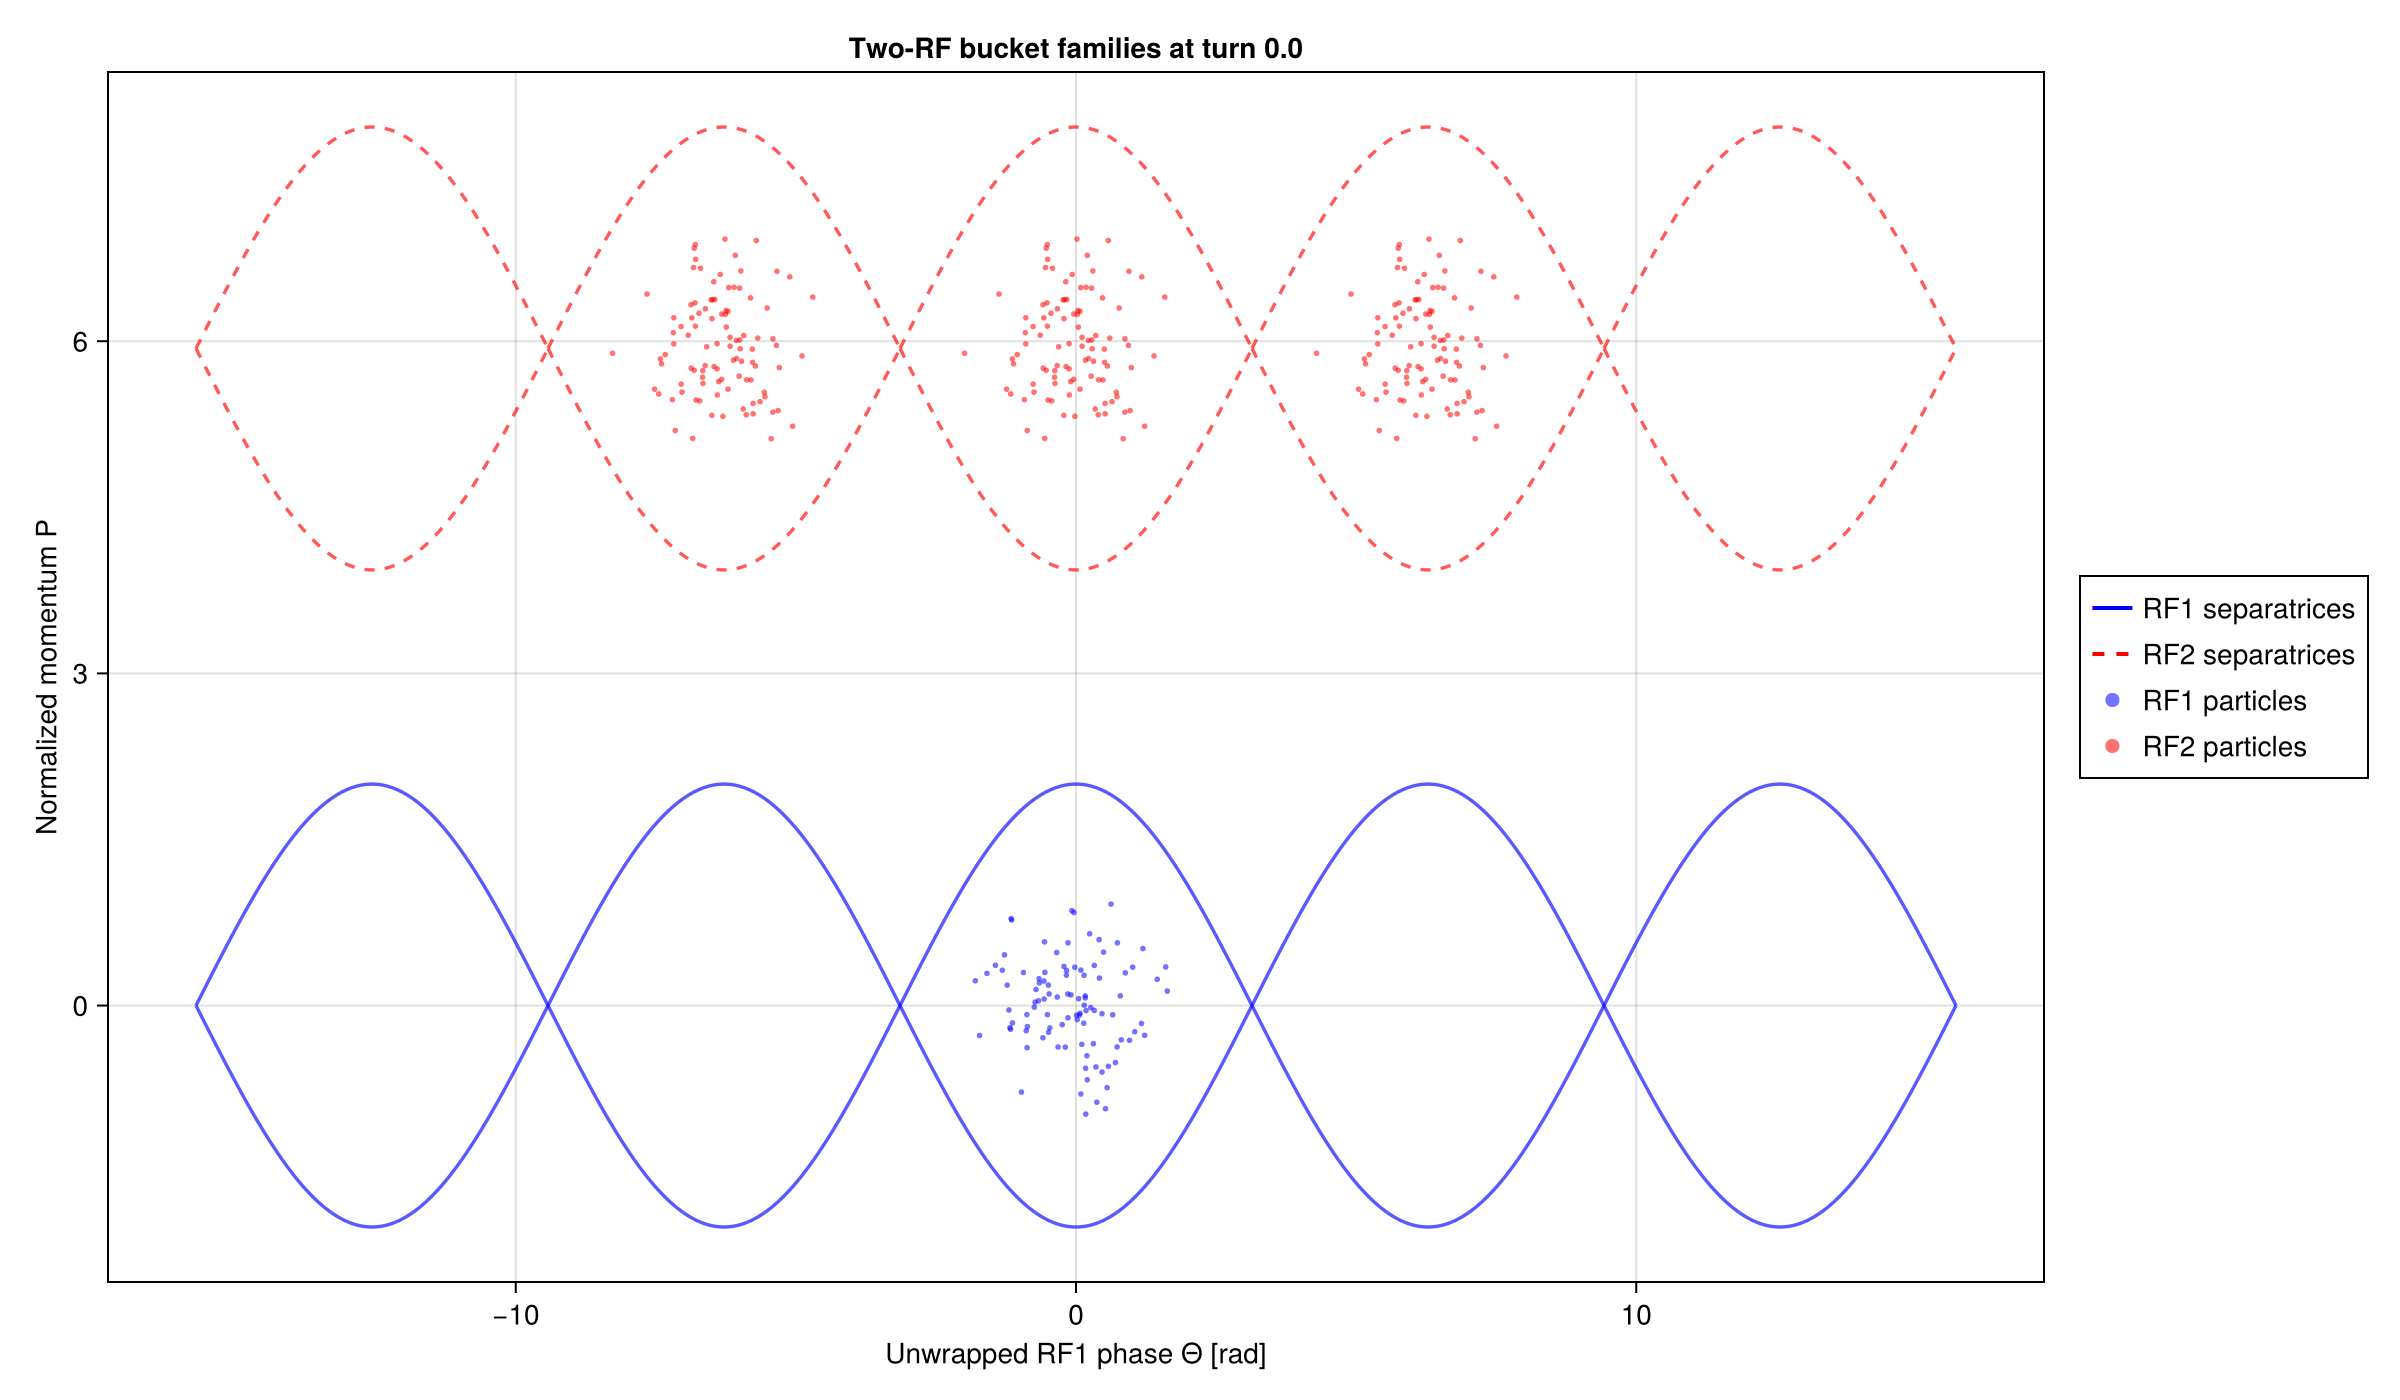

CairoMakie.Screen{IMAGE}


In [5]:
# ------------------------------------------------------------
# Select turn and buckets to display
# ------------------------------------------------------------

turn_index = 1
turn_value = turns[turn_index]

# Choose enough neighboring buckets to cover the plot
rf1_separatrix_buckets = -2:2
rf2_separatrix_buckets = -2:2


# ------------------------------------------------------------
# Local single-bucket separatrix
# ------------------------------------------------------------

theta_separatrix_local = collect(
    range(-π, π; length=500)
)

P_separatrix_upper_local =
    2 .* cos.(theta_separatrix_local ./ 2)

P_separatrix_lower_local =
    -P_separatrix_upper_local


# ------------------------------------------------------------
# RF2 momentum scaling and phase displacement
# ------------------------------------------------------------

alpha_s_value = slip_stacking_parameter(two_rf)

momentum_scale =
    synchrotron_tune(two_rf.rf2) /
    synchrotron_tune(two_rf.rf1)

# Includes relative_phase0 and accumulated slip phase
rf2_slip_phase = trajectory.slip_phase[turn_index]

P2_separatrix_upper =
    alpha_s_value .+
    momentum_scale .* P_separatrix_upper_local

P2_separatrix_lower =
    alpha_s_value .+
    momentum_scale .* P_separatrix_lower_local


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

figure = Figure(size=(1200, 700))

axis = Axis(
    figure[1, 1];
    xlabel="Unwrapped RF1 phase Θ [rad]",
    ylabel="Normalized momentum P",
    title="Two-RF bucket families at turn $(turn_value)",
    xgridvisible=true,
    ygridvisible=true,
)


# ------------------------------------------------------------
# RF1 separatrices
# ------------------------------------------------------------

for bucket_index in rf1_separatrix_buckets

    theta1_separatrix_absolute =
        theta_separatrix_local .+
        2π * bucket_index

    lines!(
        axis,
        theta1_separatrix_absolute,
        P_separatrix_upper_local;
        color=(:blue, 0.65),
        linewidth=1.7,
    )

    lines!(
        axis,
        theta1_separatrix_absolute,
        P_separatrix_lower_local;
        color=(:blue, 0.65),
        linewidth=1.7,
    )
end


# ------------------------------------------------------------
# RF2 separatrices in the unwrapped RF1 frame
# ------------------------------------------------------------

for bucket_index in rf2_separatrix_buckets

    theta2_separatrix_absolute =
        theta_separatrix_local .+
        2π * bucket_index .+
        rf2_slip_phase

    lines!(
        axis,
        theta2_separatrix_absolute,
        P2_separatrix_upper;
        color=(:red, 0.65),
        linewidth=1.7,
        linestyle=:dash,
    )

    lines!(
        axis,
        theta2_separatrix_absolute,
        P2_separatrix_lower;
        color=(:red, 0.65),
        linewidth=1.7,
        linestyle=:dash,
    )
end


# ------------------------------------------------------------
# Particle distributions
# ------------------------------------------------------------

for bunch in rf1_bunches
    scatter!(
        axis,
        bunch.theta_absolute[turn_index, :],
        bunch.P[turn_index, :];
        color=(:blue, 0.55),
        markersize=4,
    )
end

for bunch in rf2_bunches
    scatter!(
        axis,
        bunch.theta_absolute[turn_index, :],
        bunch.P[turn_index, :];
        color=(:red, 0.55),
        markersize=4,
    )
end


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

Legend(
    figure[1, 2],
    [
        LineElement(
            color=:blue,
            linewidth=2,
        ),
        LineElement(
            color=:red,
            linewidth=2,
            linestyle=:dash,
        ),
        MarkerElement(
            color=(:blue, 0.55),
            marker=:circle,
            markersize=10,
        ),
        MarkerElement(
            color=(:red, 0.55),
            marker=:circle,
            markersize=10,
        ),
    ],
    [
        "RF1 separatrices",
        "RF2 separatrices",
        "RF1 particles",
        "RF2 particles",
    ],
)

display(figure)

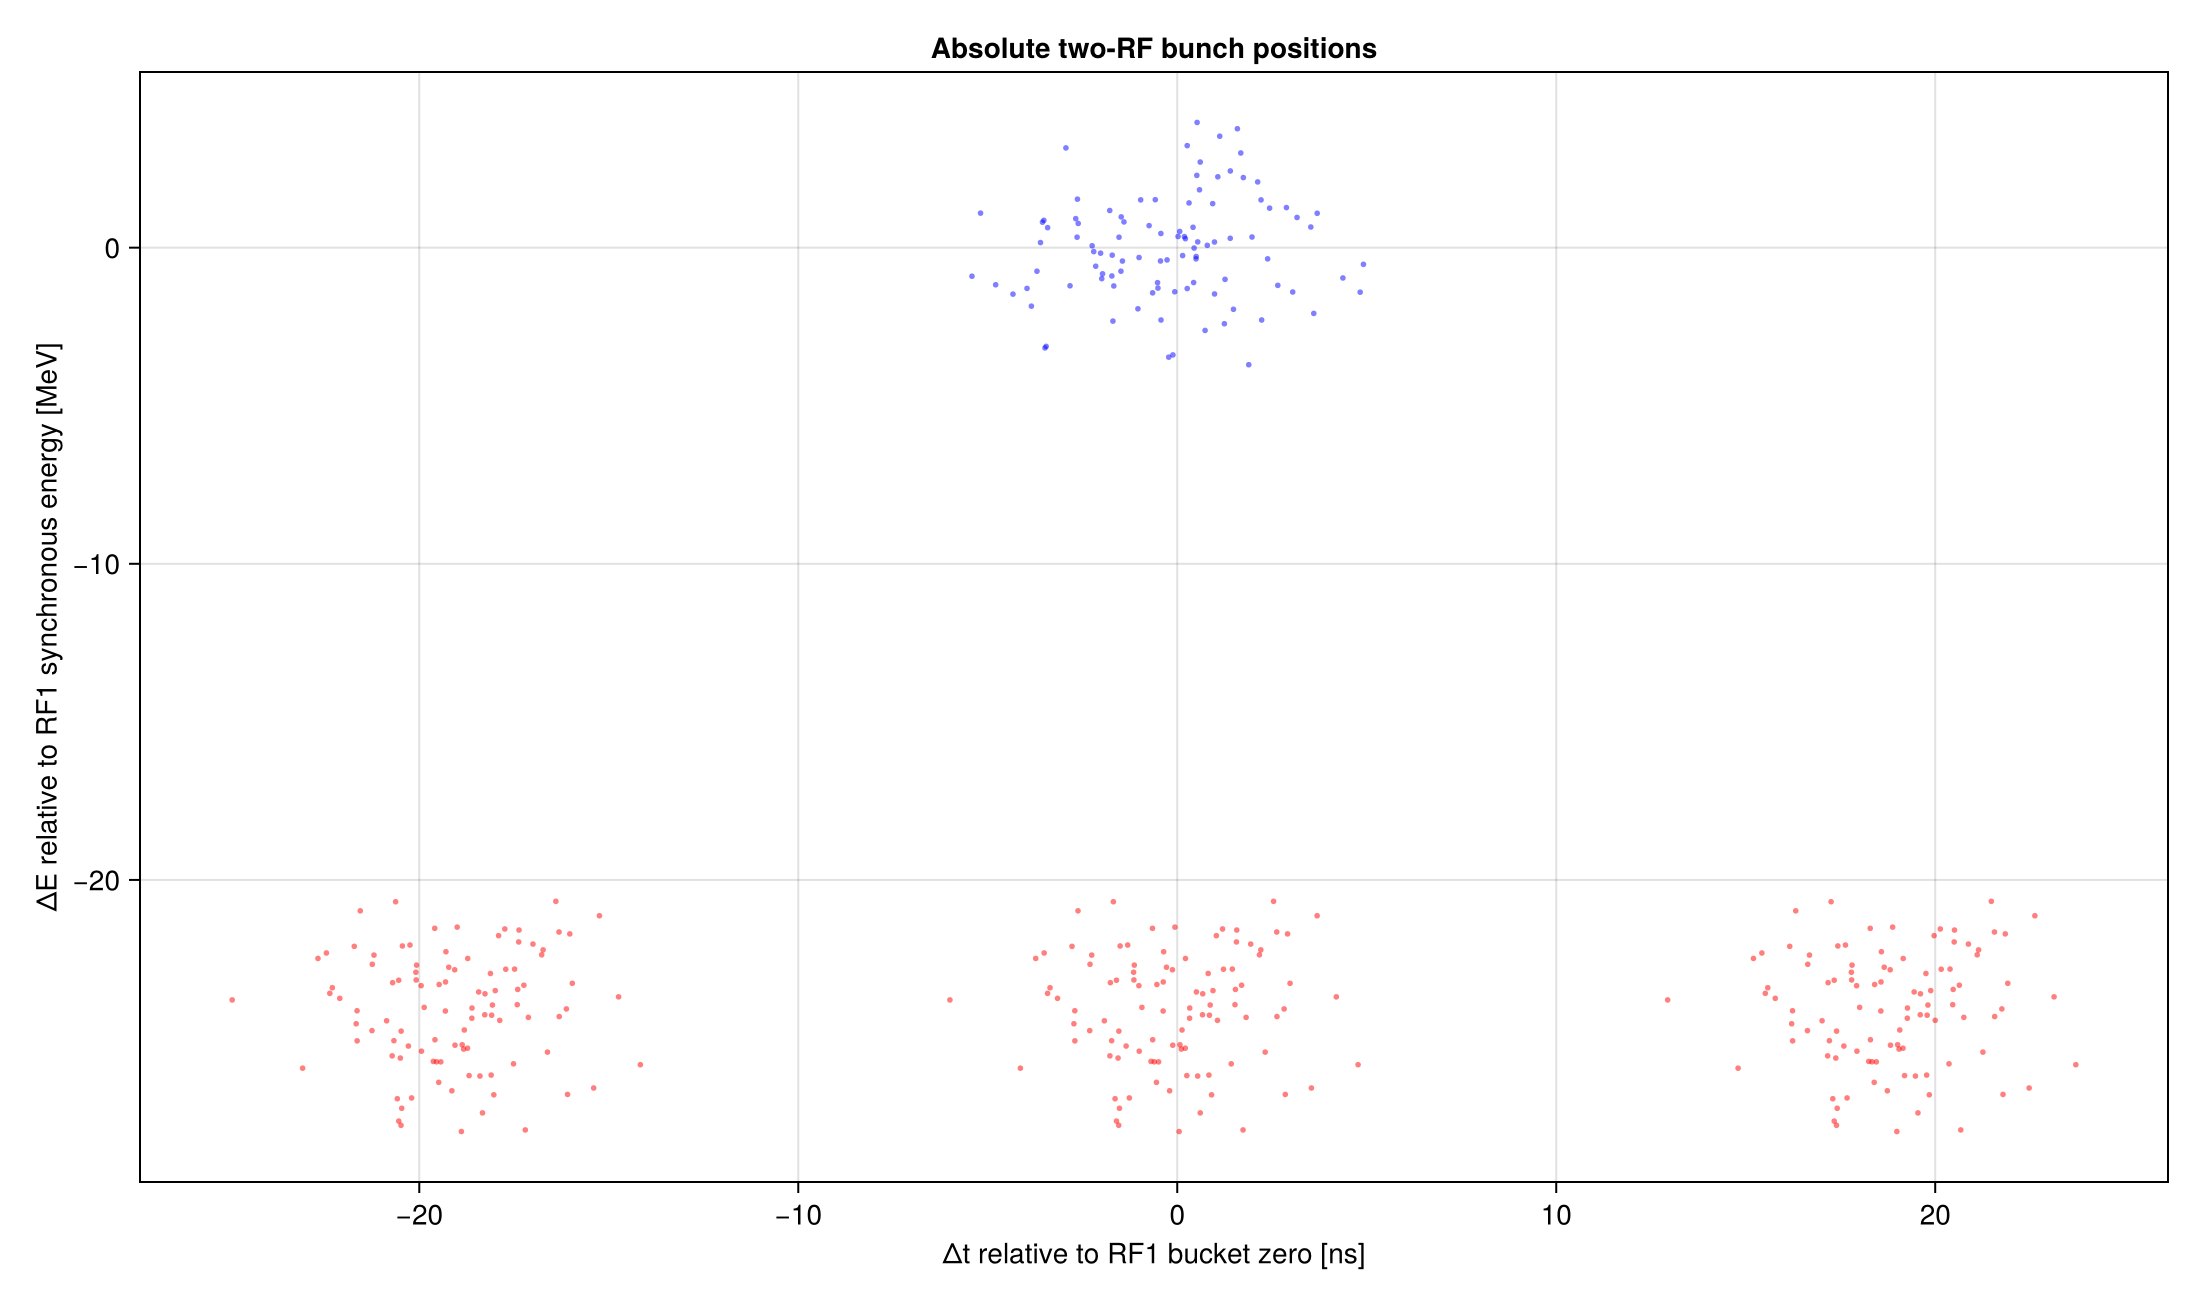

CairoMakie.Screen{IMAGE}


In [6]:
turn_index = 1  # initial distribution

figure = Figure(size=(1100, 650))

axis = Axis(
    figure[1, 1];
    xlabel="Δt relative to RF1 bucket zero [ns]",
    ylabel="ΔE relative to RF1 synchronous energy [MeV]",
    title="Absolute two-RF bunch positions",
)

for bunch in rf1_bunches
    scatter!(
        axis,
        bunch.delta_t[turn_index, :] .* 1e9,
        bunch.delta_E[turn_index, :] .* 1e-6;
        color=(:blue, 0.5),
        markersize=4,
    )
end

for bunch in rf2_bunches
    scatter!(
        axis,
        bunch.delta_t[turn_index, :] .* 1e9,
        bunch.delta_E[turn_index, :] .* 1e-6;
        color=(:red, 0.5),
        markersize=4,
    )
end

display(figure)

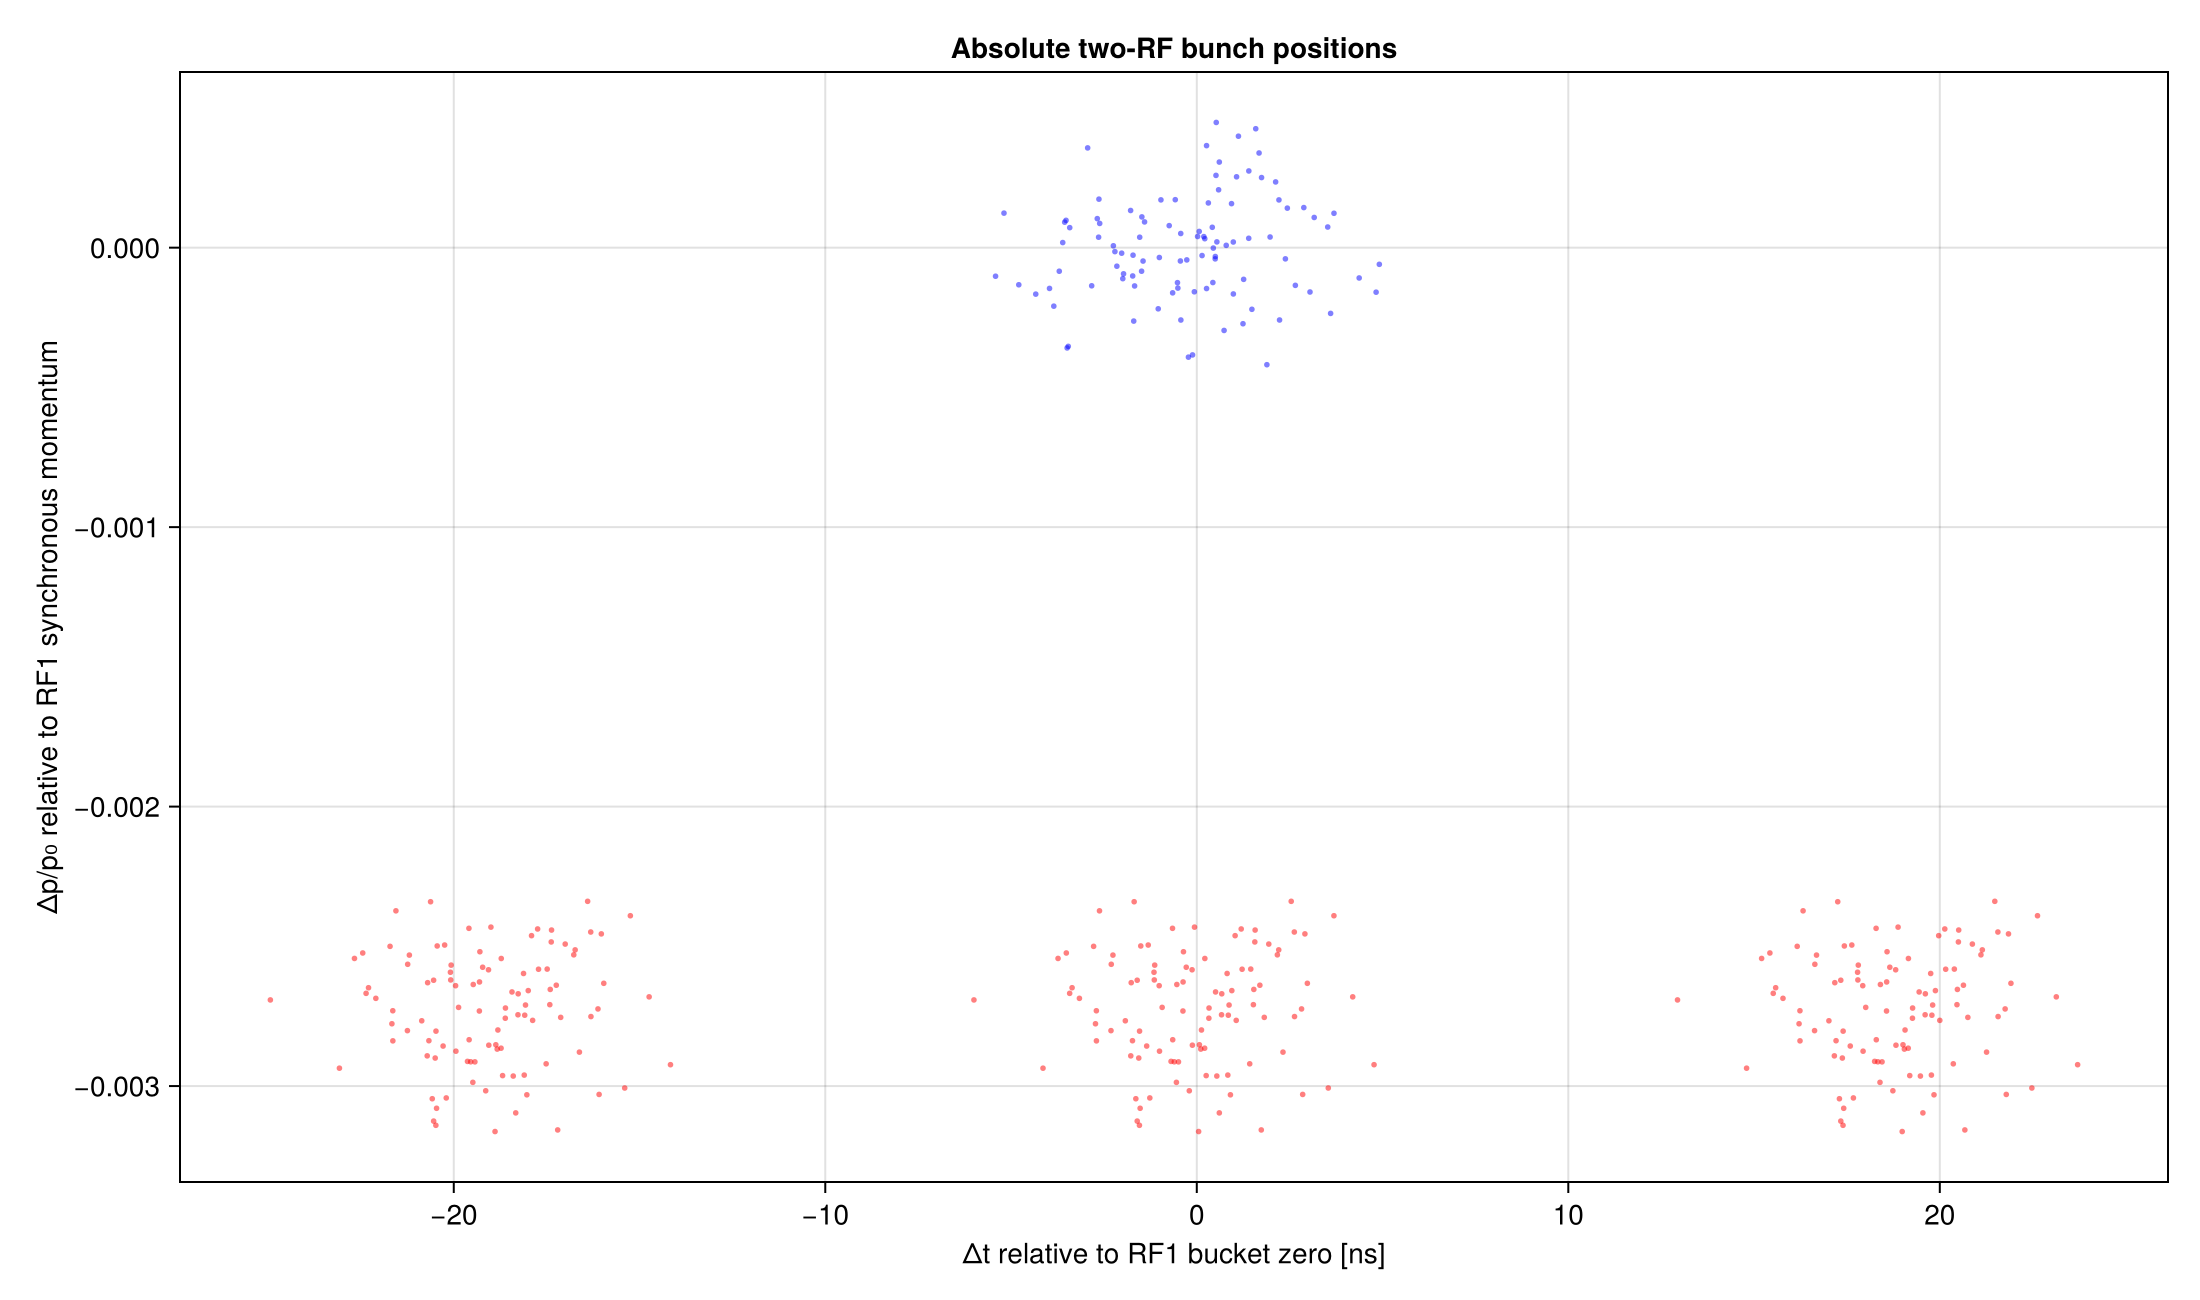

CairoMakie.Screen{IMAGE}


In [7]:
turn_index = 1  # initial distribution

figure = Figure(size=(1100, 650))

axis = Axis(
    figure[1, 1];
    xlabel="Δt relative to RF1 bucket zero [ns]",
    ylabel="Δp/p₀ relative to RF1 synchronous momentum",
    title="Absolute two-RF bunch positions",
)

for bunch in rf1_bunches
    scatter!(
        axis,
        bunch.delta_t[turn_index, :] .* 1e9,
        bunch.delta_p_over_p0[turn_index, :];
        color=(:blue, 0.5),
        markersize=4,
    )
end

for bunch in rf2_bunches
    scatter!(
        axis,
        bunch.delta_t[turn_index, :] .* 1e9,
        bunch.delta_p_over_p0[turn_index, :];
        color=(:red, 0.5),
        markersize=4,
    )
end

display(figure)

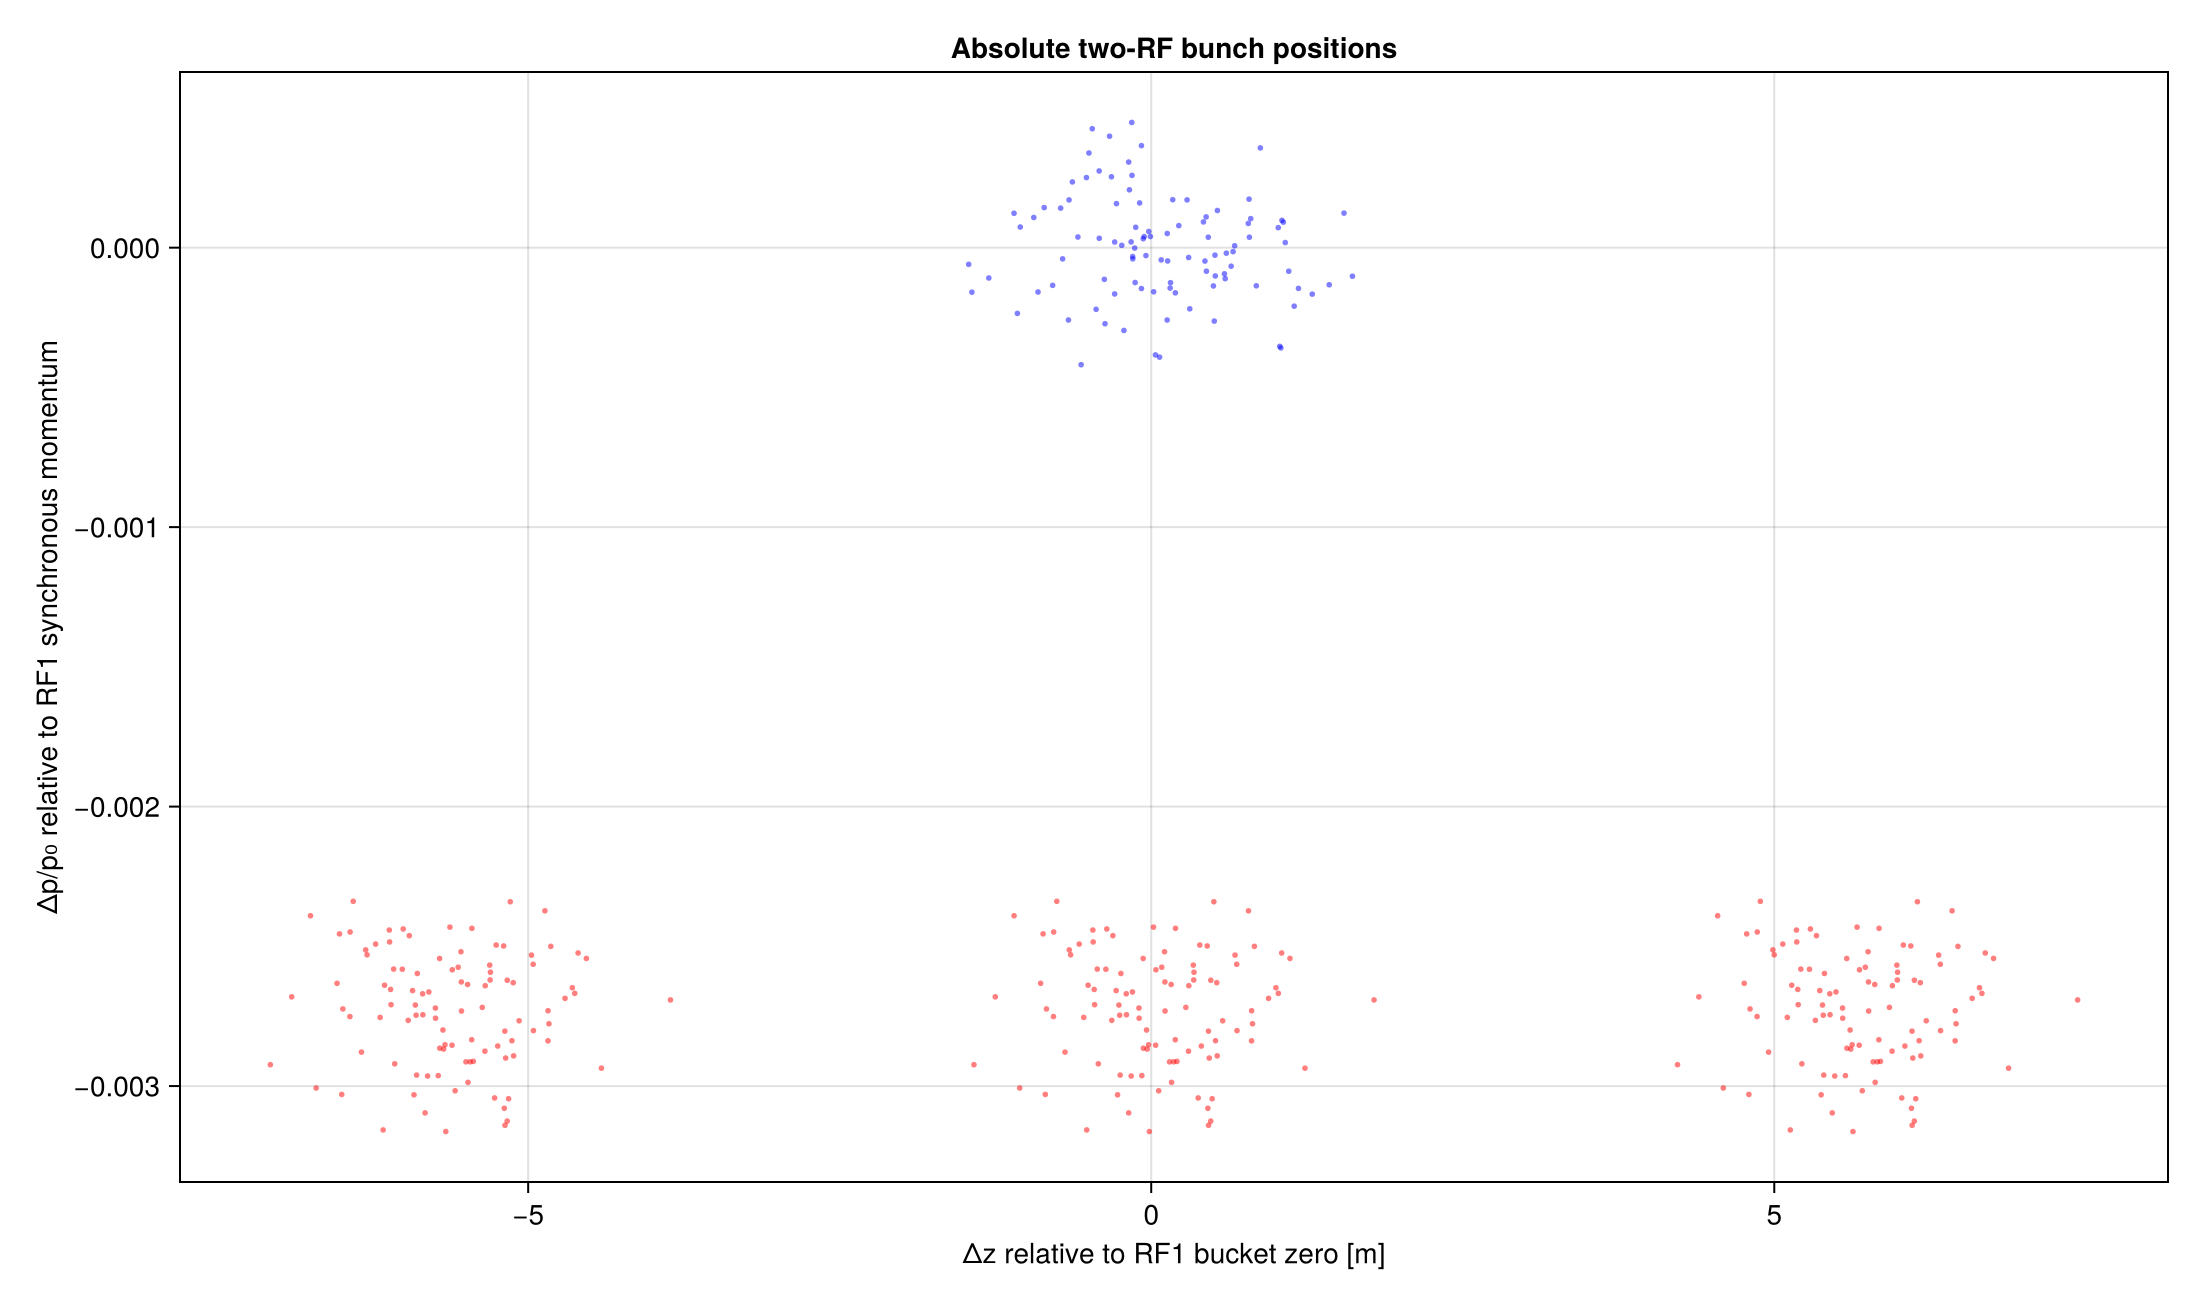

CairoMakie.Screen{IMAGE}


In [8]:
turn_index = 1  # initial distribution

figure = Figure(size=(1100, 650))

axis = Axis(
    figure[1, 1];
    xlabel="Δz relative to RF1 bucket zero [m]",
    ylabel="Δp/p₀ relative to RF1 synchronous momentum",
    title="Absolute two-RF bunch positions",
)

for bunch in rf1_bunches
    scatter!(
        axis,
        bunch.z[turn_index, :] ,
        bunch.delta_p_over_p0[turn_index, :];
        color=(:blue, 0.5),
        markersize=4,
    )
end

for bunch in rf2_bunches
    scatter!(
        axis,
        bunch.z[turn_index, :] ,
        bunch.delta_p_over_p0[turn_index, :];
        color=(:red, 0.5),
        markersize=4,
    )
end

display(figure)

In [9]:
# ------------------------------------------------------------
# RWCM cascades from the currently placed bunch distributions
# ------------------------------------------------------------

using Printf

all_bunches = [rf1_bunches...; rf2_bunches...]

isempty(all_bunches) && error("No bunches are selected.")

# Edit these if the bunches should have unequal charge.
# By default, each selected bunch has equal charge.
rf1_bunch_charges = ones(length(rf1_bunches))
rf2_bunch_charges = ones(length(rf2_bunches))

bunch_charges = Float64.([rf1_bunch_charges...; rf2_bunch_charges...])

normalize_total_charge = true
if normalize_total_charge
    bunch_charges ./= sum(bunch_charges)
end

"""
Stacks a field from multiple bunches into a single matrix.
"""
function stack_bunch_field(bunches, field::Symbol)
    matrices = [getproperty(bunch, field) for bunch in bunches]
    n_rows = size(first(matrices), 1)

    all(size(matrix, 1) == n_rows for matrix in matrices) ||
        error("All bunch arrays must have the same number of turns.")

    return hcat(matrices...)
end

"""
Calculates the weights for each particle in the bunches based on their charges.
"""
function particle_weights_for_bunches(bunches, bunch_charges)
    length(bunches) == length(bunch_charges) ||
        error("bunch_charges must contain one charge per bunch.")

    return vcat([
        fill(
            Float64(bunch_charges[i]) / size(bunches[i].theta_absolute, 2),
            size(bunches[i].theta_absolute, 2),
        )
        for i in eachindex(bunches)
    ]...)
end

"""
Calculates the centers of bins that are padded with a certain fraction of the data range.
"""
function padded_bin_centers(samples; n_bins::Integer=320, pad_fraction::Real=0.04)
    n_bins > 1 || error("n_bins must be greater than 1.")

    lo = minimum(samples)
    hi = maximum(samples)
    span = hi - lo

    if span == 0
        span = max(abs(lo), 1.0)
    end

    pad = pad_fraction * span
    return collect(range(lo - pad, hi + pad; length=n_bins))
end

padded_bin_centers

In [10]:
# Samples have shape (n_turns, n_total_particles).
# This is intentionally unwrapped absolute RF1 phase/time.
theta_samples = stack_bunch_field(all_bunches, :theta_absolute)
delta_t_samples_s = stack_bunch_field(all_bunches, :delta_t)

particle_weights = particle_weights_for_bunches(
    all_bunches,
    bunch_charges,
)

n_rwcm_bins = 360

phase_bin_centers = padded_bin_centers(
    theta_samples;
    n_bins=n_rwcm_bins,
)

time_bin_centers_s = padded_bin_centers(
    delta_t_samples_s;
    n_bins=n_rwcm_bins,
)

phase_sigma = 0.75 * (phase_bin_centers[2] - phase_bin_centers[1])
time_sigma_s = 0.75 * (time_bin_centers_s[2] - time_bin_centers_s[1])

phase_profiles = soft_histogram(
    theta_samples,
    phase_bin_centers;
    sigma=phase_sigma,
    particle_weights=particle_weights,
    normalize=false,
)

time_profiles = soft_histogram(
    delta_t_samples_s,
    time_bin_centers_s;
    sigma=time_sigma_s,
    particle_weights=particle_weights,
    normalize=false,
)

phase_charge_per_turn = vec(sum(phase_profiles; dims=2))
time_charge_per_turn = vec(sum(time_profiles; dims=2))

@printf(
    "Phase cascade total charge per turn: min %.6f, max %.6f\n",
    minimum(phase_charge_per_turn),
    maximum(phase_charge_per_turn),
)

@printf(
    "Delta t cascade total charge per turn: min %.6f, max %.6f\n",
    minimum(time_charge_per_turn),
    maximum(time_charge_per_turn),
)

Phase cascade total charge per turn: min 1.000000, max 1.000000
Delta t cascade total charge per turn: min 1.000000, max 1.000000


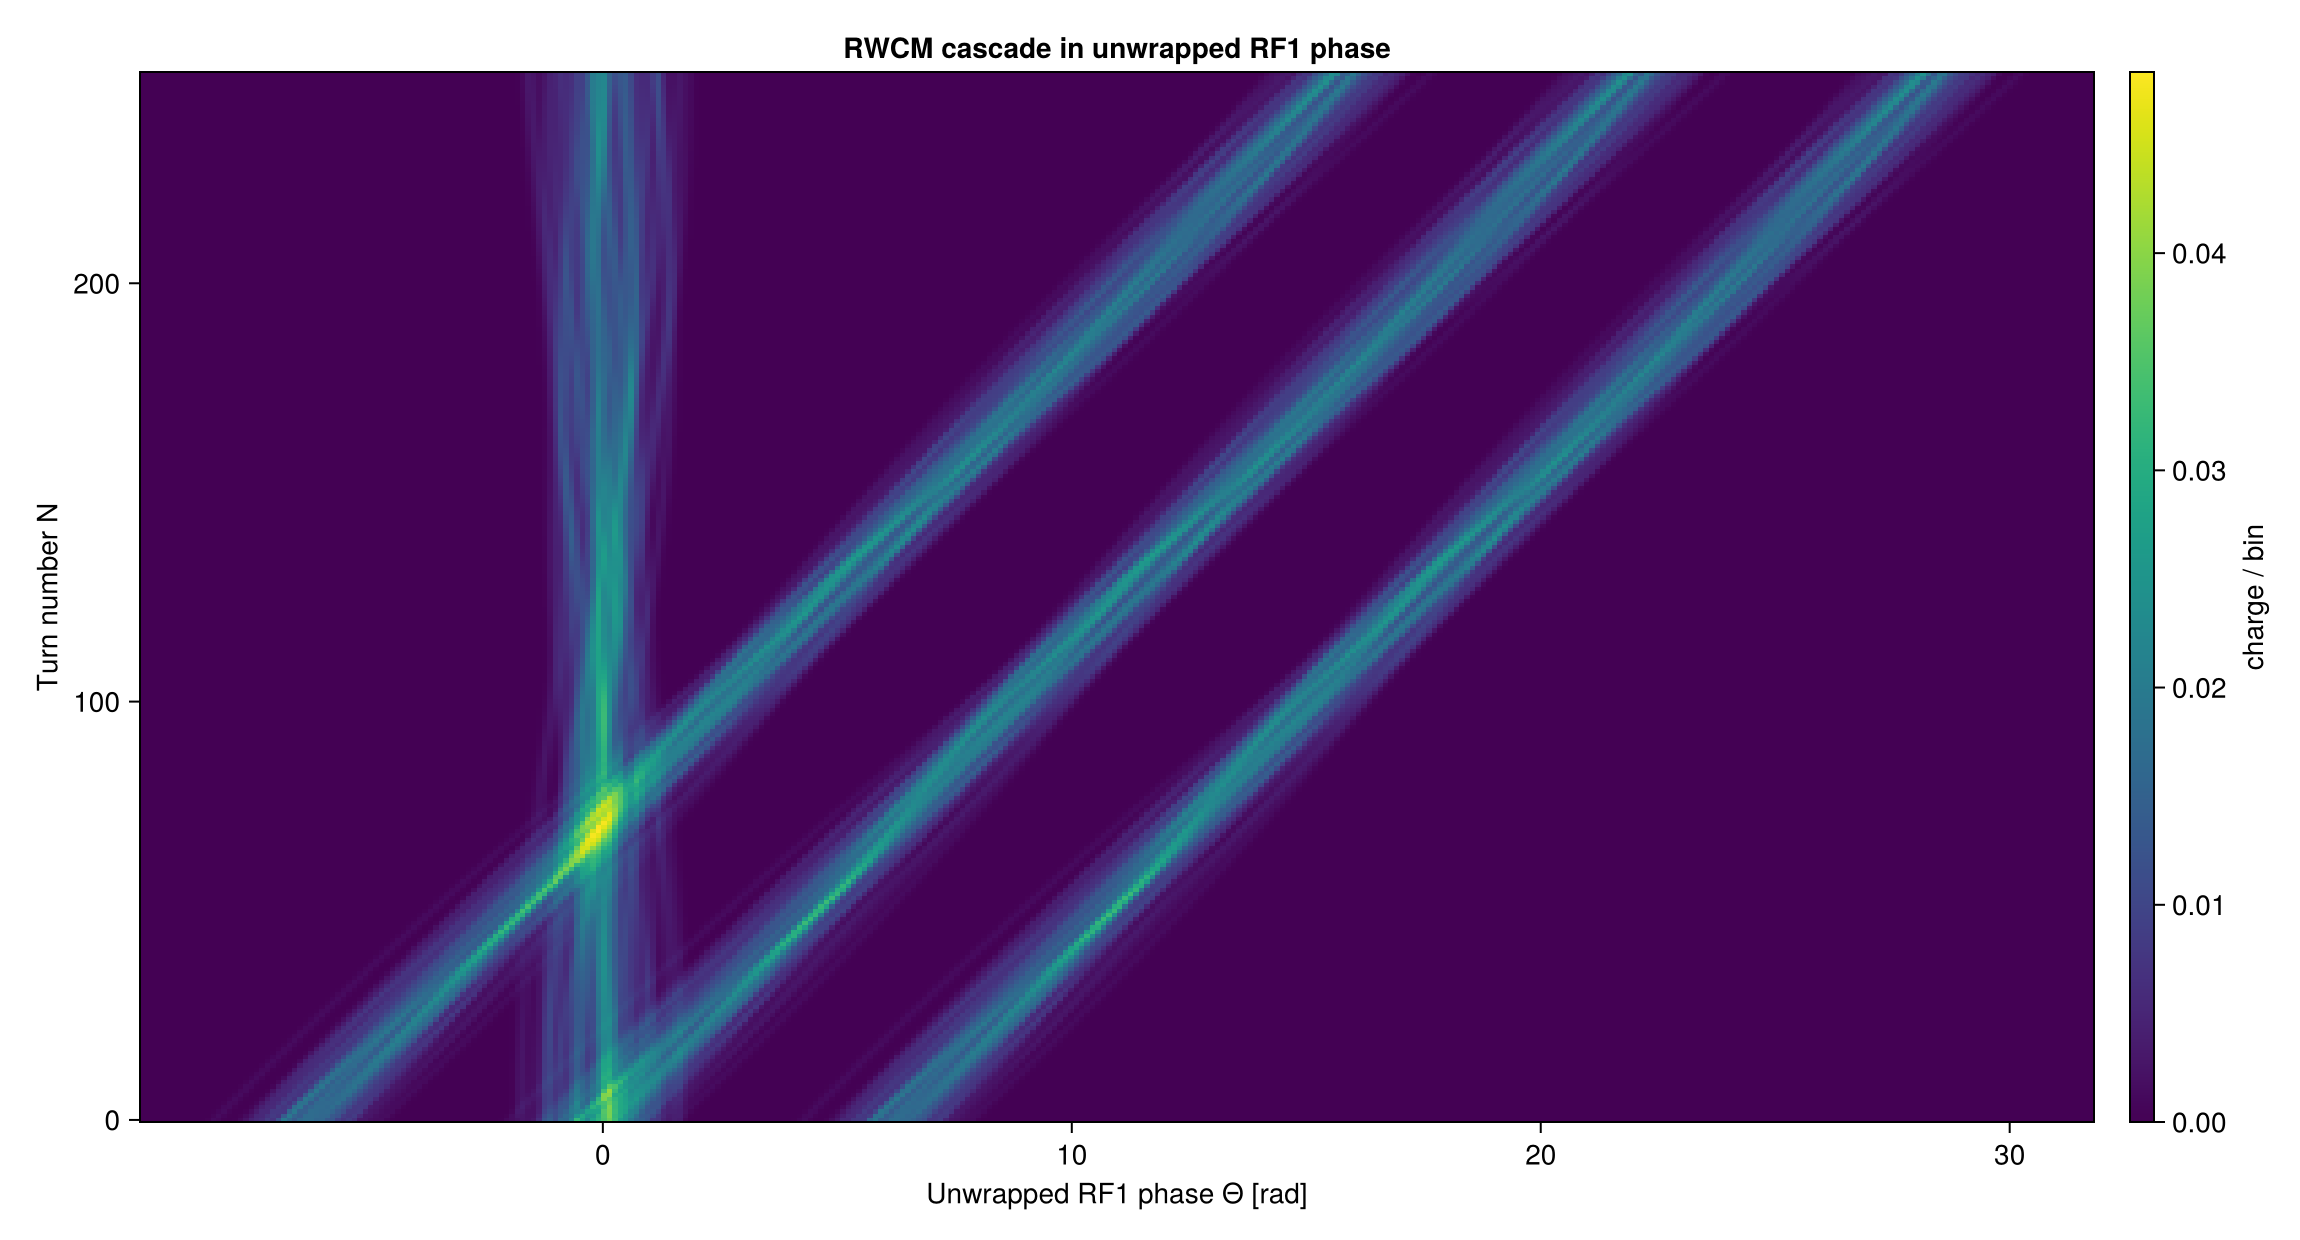

CairoMakie.Screen{IMAGE}


In [11]:

# ------------------------------------------------------------
# Cascade plot in unwrapped RF1 phase
# ------------------------------------------------------------

phase_figure = Figure(size=(1150, 620))

phase_axis = Axis(
    phase_figure[1, 1];
    xlabel="Unwrapped RF1 phase Θ [rad]",
    ylabel="Turn number N",
    title="RWCM cascade in unwrapped RF1 phase",
    xgridvisible=false,
    ygridvisible=false,
)

phase_heatmap = heatmap!(
    phase_axis,
    phase_bin_centers,
    turns,
    permutedims(phase_profiles);
    colormap=:viridis,
    colorrange=(0, maximum(phase_profiles)),
)

Colorbar(
    phase_figure[1, 2],
    phase_heatmap;
    label="charge / bin",
)

display(phase_figure)


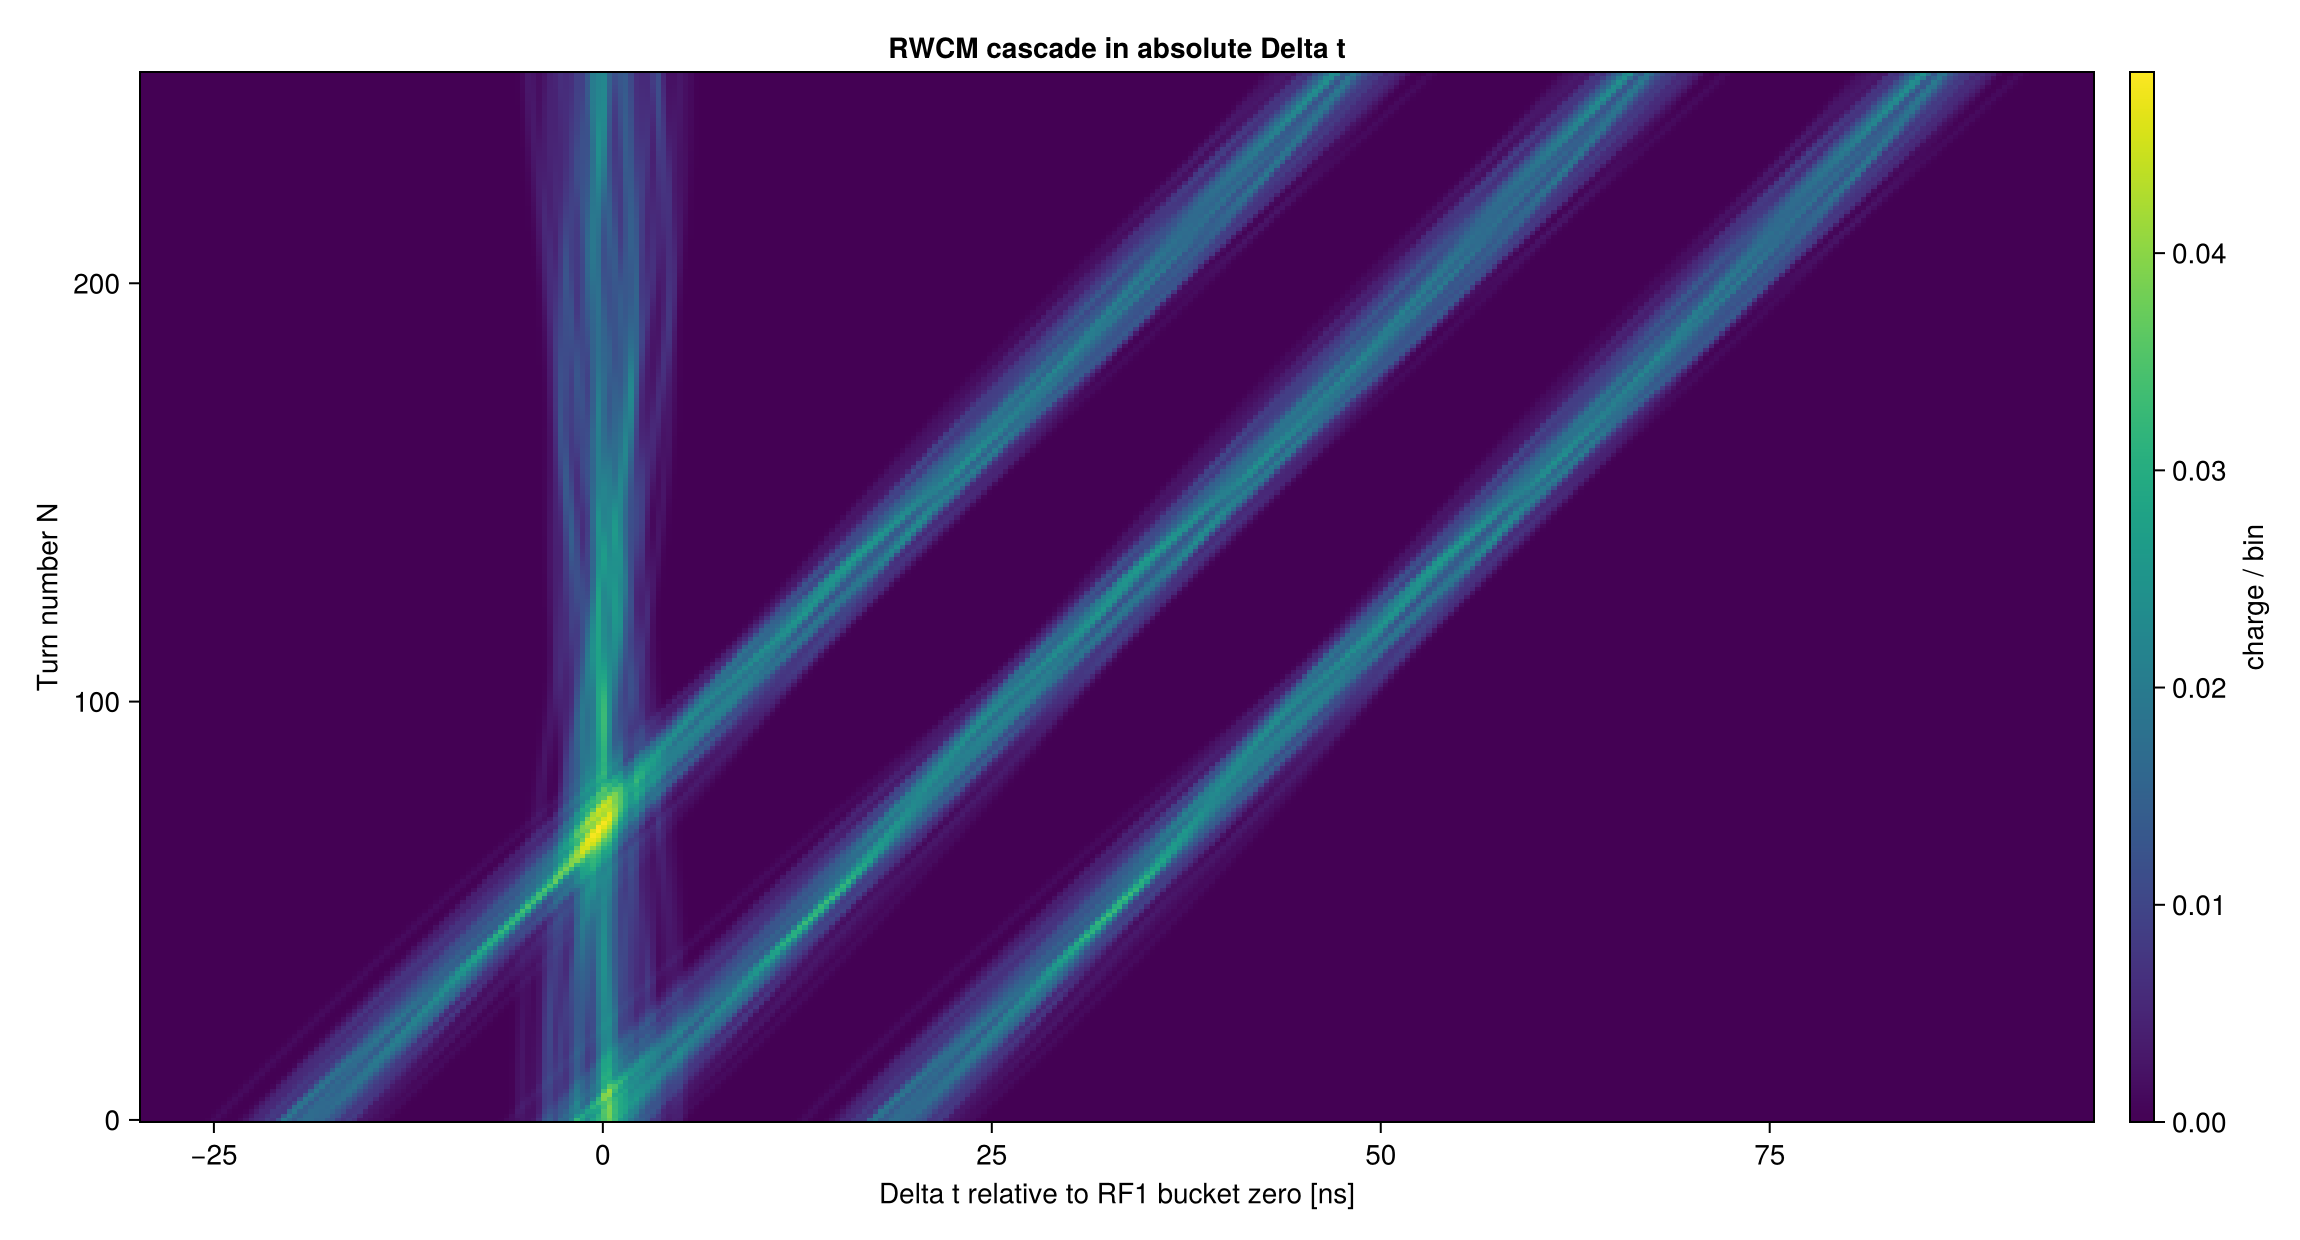

CairoMakie.Screen{IMAGE}


In [12]:
# ------------------------------------------------------------
# Cascade plot in absolute Delta t
# ------------------------------------------------------------

time_figure = Figure(size=(1150, 620))

time_axis = Axis(
    time_figure[1, 1];
    xlabel="Delta t relative to RF1 bucket zero [ns]",
    ylabel="Turn number N",
    title="RWCM cascade in absolute Delta t",
    xgridvisible=false,
    ygridvisible=false,
)

time_heatmap = heatmap!(
    time_axis,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(time_profiles);
    colormap=:viridis,
    colorrange=(0, maximum(time_profiles)),
)

Colorbar(
    time_figure[1, 2],
    time_heatmap;
    label="charge / bin",
)

display(time_figure)